In [33]:
# %%
# =========================================================
# CELL 1 — IMPORTS + GLOBAL SETUP (CLEAN)
# =========================================================

# ------------------ CORE ------------------
import os
import random
import numpy as np

# ------------------ TORCH ------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ------------------ VISION ------------------
from PIL import Image
from torchvision import transforms as T

# ------------------ LIGHTNING ------------------
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning import loggers as pl_loggers
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor

# ------------------ MODEL UTILS ------------------
from segmentation_models_pytorch.encoders import get_encoder
from segmentation_models_pytorch.base import SegmentationModel

# ------------------ METRICS / HELPERS ------------------
import matplotlib.pyplot as plt

# (we will define these later properly)
# from evaluate.utils import recompone_overlap, metric_calculate
# from util.utils import DiceLoss, sigmoid_mse_loss, get_current_consistency_weight

# =========================================================
# SEED (VERY IMPORTANT FOR REPRODUCIBILITY)
# =========================================================

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

# =========================================================
# DEVICE
# =========================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# =========================================================
# BASIC CONFIG (WE WILL EXPAND LATER)
# =========================================================

IMG_SIZE = 384        # paper uses 384
BATCH_SIZE = 8
L_BATCH_SIZE = 4      # labeled portion
U_BATCH_SIZE = BATCH_SIZE - L_BATCH_SIZE

MAX_EPOCHS = 50
LR = 3e-4
EMA_ALPHA = 0.99
T_SAMPLES = 10
BETA = 0.75

print("\nConfig Loaded")


Using device: cuda

Config Loaded


In [34]:
# %%
# =========================================================
# CELL 2 — DATA PATHS + FILE LISTS (ID-BASED SPLIT)
# =========================================================

import os
import random

# ------------------ BASE DIRECTORIES ------------------
BASE_DIR = "/home/ayushp/Caries_Detection"
DC1000_DIR = "/home/ayushp/DC1000_dataset"

# ------------------ LABELED TRAIN DATA ------------------
TRAIN_IMG_DIR  = os.path.join(BASE_DIR, "images")
TRAIN_MASK_DIR = os.path.join(BASE_DIR, "masks")

# ------------------ TEST DATA (ORG TEST DATASET) ------------------
TEST_IMG_DIR  = os.path.join(DC1000_DIR, "org_test_dataset", "images")
TEST_MASK_DIR = os.path.join(DC1000_DIR, "org_test_dataset", "labels")

# =========================================================
# CHECK PATHS
# =========================================================

print("\nChecking paths...\n")

paths = [
    TRAIN_IMG_DIR,
    TRAIN_MASK_DIR,
    TEST_IMG_DIR,
    TEST_MASK_DIR
]

for p in paths:
    print(f"{p} → {'Exists' if os.path.exists(p) else 'Not Found'}")

# =========================================================
# LOAD ALL FILES
# =========================================================

all_images = sorted([
    os.path.join(TRAIN_IMG_DIR, f)
    for f in os.listdir(TRAIN_IMG_DIR)
])

all_masks = sorted([
    os.path.join(TRAIN_MASK_DIR, f)
    for f in os.listdir(TRAIN_MASK_DIR)
])

assert len(all_images) == len(all_masks)

# =========================================================
# HELPER: EXTRACT IMAGE ID
# =========================================================

def get_id(path):
    return int(os.path.basename(path).split(".")[0])

# =========================================================
# VALIDATION SPLIT (FIRST 100 — FIXED)
# =========================================================

VAL_SIZE = 100

val_images = all_images[:VAL_SIZE]
val_masks  = all_masks[:VAL_SIZE]

remaining_images = all_images[VAL_SIZE:]
remaining_masks  = all_masks[VAL_SIZE:]

# =========================================================
# LABELED / UNLABELED SPLIT (ID BASED)
# =========================================================

train_images = []
train_masks = []
unlabeled_images = []

for img_path, mask_path in zip(remaining_images, remaining_masks):

    img_id = get_id(img_path)

    if img_id < 1558:
        train_images.append(img_path)
        train_masks.append(mask_path)
    else:
        unlabeled_images.append(img_path)

# =========================================================
# FINAL STATS
# =========================================================

print("\n===== FINAL DATA SPLIT =====")
print(f"Train Labeled     : {len(train_images)}")
print(f"Train Unlabeled   : {len(unlabeled_images)}")
print(f"Validation (100)  : {len(val_images)}")




Checking paths...

/home/ayushp/Caries_Detection/images → Exists
/home/ayushp/Caries_Detection/masks → Exists
/home/ayushp/DC1000_dataset/org_test_dataset/images → Exists
/home/ayushp/DC1000_dataset/org_test_dataset/labels → Exists

===== FINAL DATA SPLIT =====
Train Labeled     : 1360
Train Unlabeled   : 929
Validation (100)  : 100


In [35]:
# %%
# =========================================================
# CELL 3 — DATASETS (IMPROVED WITH STRONG AUGMENTATIONS)
# =========================================================

import cv2
import numpy as np
import random
from PIL import Image
from scipy.ndimage import map_coordinates, gaussian_filter

import torch
from torch.utils.data import Dataset
from torchvision import transforms as T
from torchvision.transforms import functional as TF


# =========================================================
# HELPER FUNCTIONS
# =========================================================

def apply_clahe(pil_img, clip_limit=2.0, tile_grid_size=(8, 8)):
    """
    Apply CLAHE to grayscale PIL image.
    Improves local contrast and helps detect small lesions.
    """
    img = np.array(pil_img)

    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )

    img = clahe.apply(img)

    return Image.fromarray(img)


def random_gamma(pil_img, gamma_range=(0.7, 1.5), p=0.5):
    """
    Random gamma correction.
    """
    if random.random() > p:
        return pil_img

    gamma = random.uniform(*gamma_range)

    img = np.array(pil_img).astype(np.float32) / 255.0
    img = np.power(img, gamma)
    img = np.clip(img * 255.0, 0, 255).astype(np.uint8)

    return Image.fromarray(img)


def random_contrast(pil_img, contrast_range=(0.8, 1.3), p=0.5):
    """
    Random contrast scaling.
    """
    if random.random() > p:
        return pil_img

    factor = random.uniform(*contrast_range)

    img = np.array(pil_img).astype(np.float32)
    mean = img.mean()

    img = (img - mean) * factor + mean
    img = np.clip(img, 0, 255).astype(np.uint8)

    return Image.fromarray(img)


def elastic_transform(image, mask=None, alpha=20, sigma=4, p=0.3):
    """
    Elastic deformation (U-Net style augmentation).
    Applied identically to image and mask.
    """
    if random.random() > p:
        return image, mask

    image_np = np.array(image)
    shape = image_np.shape

    dx = gaussian_filter(
        (np.random.rand(*shape) * 2 - 1),
        sigma,
        mode="reflect"
    ) * alpha

    dy = gaussian_filter(
        (np.random.rand(*shape) * 2 - 1),
        sigma,
        mode="reflect"
    ) * alpha

    x, y = np.meshgrid(
        np.arange(shape[1]),
        np.arange(shape[0])
    )

    indices = (
        np.reshape(y + dy, (-1, 1)),
        np.reshape(x + dx, (-1, 1))
    )

    # Image interpolation (bilinear)
    distorted_image = map_coordinates(
        image_np,
        indices,
        order=1,
        mode='reflect'
    ).reshape(shape)

    distorted_image = Image.fromarray(
        np.clip(distorted_image, 0, 255).astype(np.uint8)
    )

    distorted_mask = None

    if mask is not None:
        mask_np = np.array(mask)

        # Mask interpolation (nearest neighbor)
        distorted_mask = map_coordinates(
            mask_np,
            indices,
            order=0,
            mode='reflect'
        ).reshape(shape)

        distorted_mask = Image.fromarray(
            np.clip(distorted_mask, 0, 255).astype(np.uint8)
        )

    return distorted_image, distorted_mask


# =========================================================
# TRAIN DATASET
# =========================================================

class TrainDataset(Dataset):
    def __init__(self, labeled_imgs, labeled_masks, unlabeled_imgs):

        self.labeled_imgs = labeled_imgs
        self.labeled_masks = labeled_masks
        self.unlabeled_imgs = unlabeled_imgs

        # Combined list (required for TwoStreamBatchSampler)
        self.all_images = self.labeled_imgs + self.unlabeled_imgs

        # Resize
        self.resize = T.Resize((IMG_SIZE, IMG_SIZE))

        # Shared geometric augmentations
        self.affine = T.RandomAffine(
            degrees=10,
            translate=(0.05, 0.05),
            scale=(0.90, 1.10),
            shear=5,
            fill=0
        )

        # Final tensor conversion
        self.to_tensor = T.Compose([
            T.ToTensor(),
            T.Normalize(mean=[0.5], std=[0.5])
        ])

        print(f"Train Dataset Loaded: {len(self.all_images)} samples")
        print(f"  Labeled   : {len(self.labeled_imgs)}")
        print(f"  Unlabeled : {len(self.unlabeled_imgs)}")

    def __len__(self):
        return len(self.all_images)

    # -----------------------------------------------------
    # STRONG IMAGE AUGMENTATION PIPELINE
    # -----------------------------------------------------
    def augment_image(self, img):
        # CLAHE
        img = apply_clahe(img)

        # Intensity augmentations
        img = random_gamma(img, gamma_range=(0.7, 1.5), p=0.7)
        img = random_contrast(img, contrast_range=(0.8, 1.3), p=0.7)

        return img

    # -----------------------------------------------------
    # SHARED GEOMETRIC AUGMENTATION (IMAGE + MASK)
    # -----------------------------------------------------
    def geometric_augment(self, img, mask=None):
        # Random horizontal flip
        if random.random() < 0.5:
            img = TF.hflip(img)
            if mask is not None:
                mask = TF.hflip(mask)

        # Random vertical flip
        if random.random() < 0.2:
            img = TF.vflip(img)
            if mask is not None:
                mask = TF.vflip(mask)

        # Random affine (same parameters)
        angle = random.uniform(-10, 10)
        translate = (
            int(random.uniform(-0.05, 0.05) * img.size[0]),
            int(random.uniform(-0.05, 0.05) * img.size[1])
        )
        scale = random.uniform(0.90, 1.10)
        shear = random.uniform(-5, 5)

        img = TF.affine(
            img,
            angle=angle,
            translate=translate,
            scale=scale,
            shear=shear,
            interpolation=TF.InterpolationMode.BILINEAR,
            fill=0
        )

        if mask is not None:
            mask = TF.affine(
                mask,
                angle=angle,
                translate=translate,
                scale=scale,
                shear=shear,
                interpolation=TF.InterpolationMode.NEAREST,
                fill=0
            )

        # Elastic deformation
        img, mask = elastic_transform(
            img,
            mask,
            alpha=20,
            sigma=4,
            p=0.3
        )

        return img, mask

    # -----------------------------------------------------
    # GET ITEM
    # -----------------------------------------------------
    def __getitem__(self, idx):

        # =================================================
        # LABELED SAMPLE
        # =================================================
        if idx < len(self.labeled_imgs):

            img_path = self.labeled_imgs[idx]
            mask_path = self.labeled_masks[idx]

            # Load grayscale image and mask
            img = Image.open(img_path).convert("L")
            mask = Image.open(mask_path).convert("L")

            # Intensity augmentations (image only)
            img = self.augment_image(img)

            # Shared geometric augmentations
            img, mask = self.geometric_augment(img, mask)

            # Resize
            img = self.resize(img)
            mask = self.resize(mask)

            # Convert to tensors
            img = self.to_tensor(img)
            mask = T.ToTensor()(mask)

            # Binary mask
            mask = (mask > 0).float()

            return img, mask

        # =================================================
        # UNLABELED SAMPLE
        # =================================================
        else:

            unlabeled_idx = idx - len(self.labeled_imgs)
            img_path = self.unlabeled_imgs[unlabeled_idx]

            # Load grayscale image
            img = Image.open(img_path).convert("L")

            # Intensity augmentations
            img = self.augment_image(img)

            # Geometric augmentations (image only)
            img, _ = self.geometric_augment(img, None)

            # Resize
            img = self.resize(img)

            # Convert to tensor
            img = self.to_tensor(img)

            # Dummy mask (required by training pipeline)
            mask = torch.zeros(
                (1, IMG_SIZE, IMG_SIZE),
                dtype=torch.float32
            )

            return img, mask


# =========================================================
# VALIDATION DATASET (NO AUGMENTATION)
# =========================================================

class ValDataset(Dataset):
    def __init__(self, image_list, mask_list):

        self.image_list = image_list
        self.mask_list = mask_list

        self.resize = T.Resize((IMG_SIZE, IMG_SIZE))

        self.to_tensor = T.Compose([
            T.ToTensor(),
            T.Normalize(mean=[0.5], std=[0.5])
        ])

        print(f"Validation Dataset Loaded: {len(self.image_list)} images")

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):

        # Load grayscale image and mask
        img = Image.open(self.image_list[idx]).convert("L")
        mask = Image.open(self.mask_list[idx]).convert("L")

        # Optional mild CLAHE for evaluation consistency
        img = apply_clahe(img)

        # Resize
        img = self.resize(img)
        mask = self.resize(mask)

        # Convert to tensors
        img = self.to_tensor(img)
        mask = T.ToTensor()(mask)

        # Binary mask
        mask = (mask > 0).float()

        return img, mask


In [36]:
# =========================================================
# CELL 4 — DATALOADER + TWO STREAM SAMPLER (PAPER CORE)
# =========================================================

from torch.utils.data.sampler import Sampler
import itertools

# =========================================================
# TWO STREAM BATCH SAMPLER (CRITICAL)
# =========================================================

class TwoStreamBatchSampler(Sampler):
    """
    Iterates two sets of indices:
    - labeled indices
    - unlabeled indices

    Each batch = L labeled + U unlabeled
    """

    def __init__(self, labeled_idxs, unlabeled_idxs, batch_size, labeled_batch_size):
        self.labeled_idxs = labeled_idxs
        self.unlabeled_idxs = unlabeled_idxs
        self.labeled_batch_size = labeled_batch_size
        self.unlabeled_batch_size = batch_size - labeled_batch_size

    def __iter__(self):
        labeled_iter = self.shuffle_once(self.labeled_idxs)
        unlabeled_iter = self.shuffle_eternally(self.unlabeled_idxs)

        return (
            labeled_batch + unlabeled_batch
            for labeled_batch, unlabeled_batch in zip(
                self.grouper(labeled_iter, self.labeled_batch_size),
                self.grouper(unlabeled_iter, self.unlabeled_batch_size),
            )
        )

    def __len__(self):
        return len(self.labeled_idxs) // self.labeled_batch_size

    def shuffle_once(self, indices):
        return np.random.permutation(indices)

    def shuffle_eternally(self, indices):
        while True:
            yield from np.random.permutation(indices)

    def grouper(self, iterable, n):
        args = [iter(iterable)] * n
        return zip(*args)


# =========================================================
# CREATE DATASETS
# =========================================================

train_dataset = TrainDataset(train_images, train_masks, unlabeled_images)
val_dataset = ValDataset(val_images, val_masks)


# =========================================================
# CREATE SAMPLER INDICES
# =========================================================

total_size = len(train_dataset)
labeled_size = len(train_images)

print("\nSANITY CHECK:")
print(f"Labeled idx range: 0 → {len(train_images)-1}")
print(f"Unlabeled idx range: {len(train_images)} → {total_size-1}")

all_indices = list(range(total_size))

labeled_idxs = list(range(labeled_size))
unlabeled_idxs = list(range(labeled_size, total_size))


print("\nSampler Setup:")
print(f"Labeled samples   : {len(labeled_idxs)}")
print(f"Unlabeled samples : {len(unlabeled_idxs)}")

# =========================================================
# SAMPLER
# =========================================================

batch_sampler = TwoStreamBatchSampler(
    labeled_idxs,
    unlabeled_idxs,
    batch_size=BATCH_SIZE,
    labeled_batch_size=L_BATCH_SIZE
)

# =========================================================
# DATALOADERS
# =========================================================

train_loader = DataLoader(
    train_dataset,
    batch_sampler=batch_sampler,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,   # IMPORTANT (paper requirement)
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2
)

print("\nDataloaders Ready")

Train Dataset Loaded: 2289 samples
  Labeled   : 1360
  Unlabeled : 929
Validation Dataset Loaded: 100 images

SANITY CHECK:
Labeled idx range: 0 → 1359
Unlabeled idx range: 1360 → 2288

Sampler Setup:
Labeled samples   : 1360
Unlabeled samples : 929

Dataloaders Ready


In [37]:
# %%
# =========================================================
# CELL 4 — DATALOADER + TWO STREAM SAMPLER (PAPER CORE)
# =========================================================

from torch.utils.data.sampler import Sampler
import itertools

# =========================================================
# TWO STREAM BATCH SAMPLER (CRITICAL)
# =========================================================

class TwoStreamBatchSampler(Sampler):
    """
    Iterates two sets of indices:
    - labeled indices
    - unlabeled indices

    Each batch = L labeled + U unlabeled
    """

    def __init__(self, labeled_idxs, unlabeled_idxs, batch_size, labeled_batch_size):
        self.labeled_idxs = labeled_idxs
        self.unlabeled_idxs = unlabeled_idxs
        self.labeled_batch_size = labeled_batch_size
        self.unlabeled_batch_size = batch_size - labeled_batch_size

    def __iter__(self):
        labeled_iter = self.shuffle_once(self.labeled_idxs)
        unlabeled_iter = self.shuffle_eternally(self.unlabeled_idxs)

        return (
            labeled_batch + unlabeled_batch
            for labeled_batch, unlabeled_batch in zip(
                self.grouper(labeled_iter, self.labeled_batch_size),
                self.grouper(unlabeled_iter, self.unlabeled_batch_size),
            )
        )

    def __len__(self):
        return len(self.labeled_idxs) // self.labeled_batch_size

    def shuffle_once(self, indices):
        return np.random.permutation(indices)

    def shuffle_eternally(self, indices):
        while True:
            yield from np.random.permutation(indices)

    def grouper(self, iterable, n):
        args = [iter(iterable)] * n
        return zip(*args)


# =========================================================
# CREATE DATASETS
# =========================================================

train_dataset = TrainDataset(train_images, train_masks, unlabeled_images)
val_dataset = ValDataset(val_images, val_masks)


# =========================================================
# CREATE SAMPLER INDICES
# =========================================================

total_size = len(train_dataset)
labeled_size = len(train_images)

print("\nSANITY CHECK:")
print(f"Labeled idx range: 0 → {len(train_images)-1}")
print(f"Unlabeled idx range: {len(train_images)} → {total_size-1}")

all_indices = list(range(total_size))

labeled_idxs = list(range(labeled_size))
unlabeled_idxs = list(range(labeled_size, total_size))


print("\nSampler Setup:")
print(f"Labeled samples   : {len(labeled_idxs)}")
print(f"Unlabeled samples : {len(unlabeled_idxs)}")

# =========================================================
# SAMPLER
# =========================================================

batch_sampler = TwoStreamBatchSampler(
    labeled_idxs,
    unlabeled_idxs,
    batch_size=BATCH_SIZE,
    labeled_batch_size=L_BATCH_SIZE
)

# =========================================================
# DATALOADERS
# =========================================================

train_loader = DataLoader(
    train_dataset,
    batch_sampler=batch_sampler,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,   # IMPORTANT (paper requirement)
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2
)

print("\nDataloaders Ready")



Train Dataset Loaded: 2289 samples
  Labeled   : 1360
  Unlabeled : 929
Validation Dataset Loaded: 100 images

SANITY CHECK:
Labeled idx range: 0 → 1359
Unlabeled idx range: 1360 → 2288

Sampler Setup:
Labeled samples   : 1360
Unlabeled samples : 929

Dataloaders Ready


In [38]:
# %%
# =========================================================
# CELL 5 — IMPROVED MODEL
# ASPP + CBAM ATTENTION + BOUNDARY REFINEMENT + DEEP SUPERVISION
# Compatible with the existing MLUAModel in CELL 7
# =========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from segmentation_models_pytorch.encoders import get_encoder


# =========================================================
# BASIC CONV BLOCK
# =========================================================

class Conv3x3GNReLU(nn.Module):
    def __init__(self, in_channels, out_channels, groups=32):
        super().__init__()

        groups = min(groups, out_channels)
        while out_channels % groups != 0 and groups > 1:
            groups -= 1

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.GroupNorm(groups, out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


# =========================================================
# ATTENTION GATE
# =========================================================

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l):
        super().__init__()

        self.W_g = nn.Conv2d(F_g, F_l, kernel_size=1, bias=False)
        self.W_x = nn.Conv2d(F_l, F_l, kernel_size=1, bias=False)

        self.psi = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Conv2d(F_l, 1, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.psi(g1 + x1)

        return x * psi


# =========================================================
# CBAM — CHANNEL ATTENTION
# =========================================================

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()

        hidden = max(channels // reduction, 8)

        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, kernel_size=1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_pool = F.adaptive_avg_pool2d(x, 1)
        max_pool = F.adaptive_max_pool2d(x, 1)

        attn = self.mlp(avg_pool) + self.mlp(max_pool)
        attn = self.sigmoid(attn)

        return x * attn


# =========================================================
# CBAM — SPATIAL ATTENTION
# =========================================================

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()

        padding = kernel_size // 2

        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size=kernel_size,
            padding=padding,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_map = torch.mean(x, dim=1, keepdim=True)
        max_map, _ = torch.max(x, dim=1, keepdim=True)

        attn = torch.cat([avg_map, max_map], dim=1)
        attn = self.sigmoid(self.conv(attn))

        return x * attn


# =========================================================
# CBAM BLOCK
# =========================================================

class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.channel_attention = ChannelAttention(channels)
        self.spatial_attention = SpatialAttention()

    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x


# =========================================================
# ASPP BRANCH
# =========================================================

class ASPPBranch(nn.Module):
    def __init__(self, in_channels, out_channels, dilation):
        super().__init__()

        kernel_size = 1 if dilation == 1 else 3
        padding = 0 if dilation == 1 else dilation

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                padding=padding,
                dilation=dilation,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


# =========================================================
# ASPP MODULE
# =========================================================

class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels=256, rates=(1, 6, 12, 18)):
        super().__init__()

        branch_channels = out_channels // 4

        self.branches = nn.ModuleList([
            ASPPBranch(in_channels, branch_channels, rate)
            for rate in rates
        ])

        self.global_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, branch_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(inplace=True)
        )

        total_channels = branch_channels * (len(rates) + 1)

        self.project = nn.Sequential(
            nn.Conv2d(total_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.3)
        )

    def forward(self, x):
        size = x.shape[2:]

        outputs = [branch(x) for branch in self.branches]

        gp = self.global_pool(x)
        gp = F.interpolate(
            gp,
            size=size,
            mode="bilinear",
            align_corners=False
        )

        outputs.append(gp)

        x = torch.cat(outputs, dim=1)
        x = self.project(x)

        return x


# =========================================================
# FPN BLOCK
# =========================================================

class FPNBlock(nn.Module):
    def __init__(self, pyramid_channels, skip_channels, top_layer=False):
        super().__init__()

        self.top_layer = top_layer
        self.skip_conv = nn.Conv2d(
            skip_channels,
            pyramid_channels,
            kernel_size=1,
            bias=False
        )

        if not top_layer:
            self.attention = AttentionGate(
                pyramid_channels,
                pyramid_channels
            )

    def forward(self, x, skip=None):

        # Top layer converts encoder C5 to pyramid P5
        if self.top_layer:
            return self.skip_conv(x)

        # Upsample previous pyramid level
        x = F.interpolate(
            x,
            scale_factor=2,
            mode="nearest"
        )

        # Project skip features
        skip = self.skip_conv(skip)

        # Apply attention gate
        skip = self.attention(x, skip)

        # Merge
        return x + skip


# =========================================================
# SEGMENTATION BLOCK
# =========================================================

class SegmentationBlock(nn.Module):
    def __init__(self, in_channels, out_channels, n_upsamples=0):
        super().__init__()

        layers = []

        if n_upsamples == 0:
            layers.append(
                Conv3x3GNReLU(in_channels, out_channels)
            )
        else:
            for i in range(n_upsamples):
                layers.append(
                    Conv3x3GNReLU(
                        in_channels if i == 0 else out_channels,
                        out_channels
                    )
                )
                layers.append(
                    nn.Upsample(
                        scale_factor=2,
                        mode="bilinear",
                        align_corners=False
                    )
                )

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


# =========================================================
# WEIGHTED MERGE BLOCK
# =========================================================

class WeightedMergeBlock(nn.Module):
    def __init__(self, n_inputs=4):
        super().__init__()

        self.weights = nn.Parameter(torch.ones(n_inputs))

    def forward(self, features):
        weights = torch.softmax(self.weights, dim=0)

        out = 0
        for i, feature in enumerate(features):
            out = out + weights[i] * feature

        return out


# =========================================================
# BOUNDARY REFINEMENT HEAD
# =========================================================

class BoundaryRefinementHead(nn.Module):
    """
    Learns fine edge corrections and adds them residually.
    """

    def __init__(self, channels):
        super().__init__()

        self.refine = nn.Sequential(
            Conv3x3GNReLU(channels, channels),
            CBAM(channels),
            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(channels)
        )

        self.activation = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.refine(x)
        return self.activation(x + residual)


# =========================================================
# FPN DECODER
# =========================================================

class FPNDecoder(nn.Module):
    def __init__(
        self,
        encoder_channels,
        pyramid_channels=256,
        segmentation_channels=128
    ):
        super().__init__()

        encoder_channels = encoder_channels[::-1]

        # Pyramid construction
        self.p5 = FPNBlock(
            pyramid_channels,
            encoder_channels[0],
            top_layer=True
        )
        self.p4 = FPNBlock(
            pyramid_channels,
            encoder_channels[1]
        )
        self.p3 = FPNBlock(
            pyramid_channels,
            encoder_channels[2]
        )
        self.p2 = FPNBlock(
            pyramid_channels,
            encoder_channels[3]
        )

        # Multi-scale context enhancement
        self.aspp = ASPP(
            pyramid_channels,
            out_channels=pyramid_channels
        )

        # Segmentation blocks
        self.seg_blocks = nn.ModuleList([
            SegmentationBlock(
                pyramid_channels,
                segmentation_channels,
                n_upsamples=n
            )
            for n in [3, 2, 1, 0]
        ])

        # Learnable weighted fusion
        self.merge = WeightedMergeBlock(4)

        # Global attention after fusion
        self.cbam = CBAM(segmentation_channels)

        # Boundary refinement
        self.boundary_refine = BoundaryRefinementHead(
            segmentation_channels
        )

        # Final refinement
        self.refine = nn.Sequential(
            Conv3x3GNReLU(
                segmentation_channels,
                segmentation_channels
            ),
            Conv3x3GNReLU(
                segmentation_channels,
                segmentation_channels
            )
        )

        self.dropout = nn.Dropout2d(0.3)

        self.out_channels = segmentation_channels

    def forward(self, *features):

        # Use last four encoder stages
        c2, c3, c4, c5 = features[-4:]

        # FPN pyramid
        p5 = self.p5(c5)
        p5 = self.aspp(p5)   # ASPP on top-level feature

        p4 = self.p4(p5, c4)
        p3 = self.p3(p4, c3)
        p2 = self.p2(p3, c2)

        pyramid = [p5, p4, p3, p2]

        # Convert all pyramid levels to same resolution
        seg_features = [
            seg_block(feature)
            for seg_block, feature in zip(self.seg_blocks, pyramid)
        ]

        # Weighted fusion
        x = self.merge(seg_features)

        # Attention refinement
        x = self.cbam(x)

        # Boundary refinement
        x = self.boundary_refine(x)

        # Final convolution refinement
        x = self.refine(x)

        # Regularization
        x = self.dropout(x)

        return x, seg_features


# =========================================================
# SEGMENTATION HEAD
# =========================================================

class SegmentationHead(nn.Sequential):
    def __init__(self, in_channels, out_channels, upsampling=4):
        super().__init__(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1
            ),
            nn.UpsamplingBilinear2d(
                scale_factor=upsampling
            )
        )


# =========================================================
# FINAL NETWORK
# =========================================================

class FPNNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = get_encoder(
            "resnet34",
            in_channels=1,
            depth=5,
            weights="imagenet"
        )

        # Decoder
        self.decoder = FPNDecoder(
            self.encoder.out_channels,
            pyramid_channels=256,
            segmentation_channels=128
        )

        # Main segmentation head
        self.seg_head = SegmentationHead(
            in_channels=self.decoder.out_channels,
            out_channels=1,
            upsampling=4
        )

        # Deep supervision heads
        self.aux_heads = nn.ModuleList([
            SegmentationHead(
                in_channels=128,
                out_channels=1,
                upsampling=4
            )
            for _ in range(4)
        ])

    def forward(self, x):

        # Encoder features
        features = self.encoder(x)

        # Decoder output + pyramid features
        decoder_output, pyramid_features = self.decoder(*features)

        # Main output
        main_mask = self.seg_head(decoder_output)

        # Auxiliary outputs for deep supervision
        aux_outputs = [
            head(feature)
            for head, feature in zip(
                self.aux_heads,
                pyramid_features
            )
        ]

        return main_mask, aux_outputs



In [39]:
# %%
# =========================================================
# CELL 6 — FINAL AMP-SAFE VERSION
# FIXES:
# - CPU/GPU mismatch
# - Mixed precision (float16) compatibility
# - Boundary loss works with CUDA + AMP
# =========================================================

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


# =========================================================
# METRICS
# =========================================================

def mean_metric(preds, target):
    preds = (preds > 0.5).float().view(-1)
    target = (target > 0).float().view(-1)

    TP = (preds * target).sum()
    FN = ((1.0 - preds) * target).sum()
    TN = ((1.0 - preds) * (1.0 - target)).sum()
    FP = (preds * (1.0 - target)).sum()

    eps = 1e-6

    acc  = (TP + TN) / (TP + TN + FP + FN + eps)
    iou  = TP / (TP + FP + FN + eps)
    dice = (2.0 * TP) / (2.0 * TP + FP + FN + eps)
    pre  = TP / (TP + FP + eps)
    spe  = TN / (TN + FP + eps)
    sen  = TP / (TP + FN + eps)

    return acc, iou, dice, pre, spe, sen


# =========================================================
# ADAPTIVE TVERSKY LOSS
# =========================================================

class AdaptiveTverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, gamma=0.75):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma

    def forward(self, pred, target):
        pred = torch.sigmoid(pred)

        pred = pred.reshape(pred.size(0), -1)
        target = target.reshape(target.size(0), -1)

        TP = (pred * target).sum(dim=1)
        FP = ((1.0 - target) * pred).sum(dim=1)
        FN = (target * (1.0 - pred)).sum(dim=1)

        eps = 1e-6

        tversky = (TP + eps) / (
            TP + self.alpha * FP + self.beta * FN + eps
        )

        return ((1.0 - tversky) ** self.gamma).mean()


# =========================================================
# FOCAL TVERSKY LOSS
# =========================================================

class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, gamma=1.33):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma

    def forward(self, pred, target):
        pred = torch.sigmoid(pred)

        pred = pred.reshape(pred.size(0), -1)
        target = target.reshape(target.size(0), -1)

        TP = (pred * target).sum(dim=1)
        FP = ((1.0 - target) * pred).sum(dim=1)
        FN = (target * (1.0 - pred)).sum(dim=1)

        eps = 1e-6

        tversky = (TP + eps) / (
            TP + self.alpha * FP + self.beta * FN + eps
        )

        return ((1.0 - tversky) ** self.gamma).mean()


# =========================================================
# WEIGHTED BCE LOSS (DEVICE SAFE)
# =========================================================

class WeightedBCELoss(nn.Module):
    def __init__(self, pos_weight=10.0):
        super().__init__()
        self.pos_weight_value = float(pos_weight)

    def forward(self, pred, target):
        target = target.to(device=pred.device, dtype=pred.dtype)

        pos_weight = torch.tensor(
            [self.pos_weight_value],
            device=pred.device,
            dtype=pred.dtype
        )

        return F.binary_cross_entropy_with_logits(
            pred,
            target,
            pos_weight=pos_weight,
            reduction="mean"
        )


# =========================================================
# BOUNDARY LOSS (AMP SAFE)
# =========================================================

class BoundaryLoss(nn.Module):
    def __init__(self):
        super().__init__()

        # Keep kernels as regular tensors; move dynamically each forward pass
        self.sobel_x = torch.tensor(
            [[-1, 0, 1],
             [-2, 0, 2],
             [-1, 0, 1]],
            dtype=torch.float32
        ).view(1, 1, 3, 3)

        self.sobel_y = torch.tensor(
            [[-1, -2, -1],
             [ 0,  0,  0],
             [ 1,  2,  1]],
            dtype=torch.float32
        ).view(1, 1, 3, 3)

    def get_edges(self, x):
        # Move kernels to EXACT same device and dtype as input
        sobel_x = self.sobel_x.to(device=x.device, dtype=x.dtype)
        sobel_y = self.sobel_y.to(device=x.device, dtype=x.dtype)

        gx = F.conv2d(x, sobel_x, padding=1)
        gy = F.conv2d(x, sobel_y, padding=1)

        return torch.sqrt(gx ** 2 + gy ** 2 + 1e-6)

    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        target = target.to(device=pred.device, dtype=pred.dtype)

        pred_edges = self.get_edges(pred)
        target_edges = self.get_edges(target)

        return F.l1_loss(pred_edges, target_edges)


# =========================================================
# LOSS INSTANCES
# =========================================================

tversky_loss_fn = AdaptiveTverskyLoss(
    alpha=0.3,
    beta=0.7,
    gamma=0.75
)

weighted_bce_fn = WeightedBCELoss(
    pos_weight=10.0
)

focal_tversky_fn = FocalTverskyLoss(
    alpha=0.3,
    beta=0.7,
    gamma=1.33
)

boundary_loss_fn = BoundaryLoss()


# =========================================================
# FINAL SEGMENTATION LOSS
# =========================================================

def segmentation_loss(pred, target):
    target = target.to(device=pred.device, dtype=pred.dtype)

    loss_tversky = tversky_loss_fn(pred, target)
    loss_bce = weighted_bce_fn(pred, target)
    loss_focal_tversky = focal_tversky_fn(pred, target)
    loss_boundary = boundary_loss_fn(pred, target)

    total_loss = (
        0.35 * loss_tversky +
        0.25 * loss_bce +
        0.25 * loss_focal_tversky +
        0.15 * loss_boundary
    )

    total_loss = torch.nan_to_num(
        total_loss,
        nan=0.0,
        posinf=10.0,
        neginf=0.0
    )

    return total_loss


# =========================================================
# CONSISTENCY LOSS
# =========================================================

def sigmoid_mse_loss(input_logits, target_probs):
    student_probs = torch.sigmoid(input_logits)

    target_probs = target_probs.to(
        device=input_logits.device,
        dtype=input_logits.dtype
    )

    return F.mse_loss(
        student_probs,
        target_probs,
        reduction="none"
    )


# =========================================================
# SIGMOID RAMP-UP
# =========================================================

def sigmoid_rampup(current, rampup_length):
    if rampup_length == 0:
        return 1.0

    current = np.clip(current, 0.0, rampup_length)
    phase = 1.0 - current / rampup_length

    return float(np.exp(-5.0 * phase * phase))


def get_current_consistency_weight(epoch, max_epoch):
    return 0.2 * sigmoid_rampup(epoch, max_epoch)


# =========================================================
# UNCERTAINTY ESTIMATION
# =========================================================

def compute_uncertainty(preds):
    preds = torch.stack(preds, dim=0)  # [T, B, 1, H, W]

    mean_pred = preds.mean(dim=0)

    uncertainty = -(
        mean_pred * torch.log(mean_pred + 1e-6) +
        (1.0 - mean_pred) * torch.log(1.0 - mean_pred + 1e-6)
    )

    return mean_pred, uncertainty



In [40]:
# %%
# =========================================================
# CELL 7 — MLUAModel (FINAL IMPROVED VERSION)
# Teacher-Student Semi-Supervised Learning with:
# - Deep Supervision
# - Uncertainty Filtering
# - Dynamic Consistency Weighting
# - Teacher EMA Stabilization
# - Monte Carlo Teacher Sampling
# - Robust Validation Metrics
# =========================================================

import numpy as np
import torch
import torch.nn.functional as F
import pytorch_lightning as pl


class MLUAModel(pl.LightningModule):
    def __init__(self):
        super().__init__()

        # -------------------------------------------------
        # NETWORKS
        # -------------------------------------------------
        self.student = FPNNet()
        self.teacher = FPNNet()

        # Initialize teacher from student
        self.teacher.load_state_dict(self.student.state_dict())

        # Teacher parameters are frozen
        for p in self.teacher.parameters():
            p.requires_grad = False

        # Save hyperparameters for checkpointing
        self.save_hyperparameters(ignore=["student", "teacher"])

    # -----------------------------------------------------
    # FORWARD
    # -----------------------------------------------------
    def forward(self, x):
        """
        Returns only the main segmentation logits from student.
        """
        main_logits, _ = self.student(x)
        return main_logits

    # -----------------------------------------------------
    # DYNAMIC EMA DECAY
    # -----------------------------------------------------
    def get_ema_decay(self):
        """
        EMA coefficient increases gradually during training.
        Early epochs: teacher adapts faster.
        Later epochs: teacher becomes more stable.
        """
        progress = min(
            float(self.current_epoch) / max(1, MAX_EPOCHS - 1),
            1.0
        )

        # 0.95 -> EMA_ALPHA (e.g., 0.99)
        alpha = 0.95 + (EMA_ALPHA - 0.95) * progress
        return min(alpha, EMA_ALPHA)

    # -----------------------------------------------------
    # TEACHER UPDATE
    # -----------------------------------------------------
    @torch.no_grad()
    def update_teacher(self):
        """
        Exponential Moving Average update:
        teacher = alpha * teacher + (1 - alpha) * student
        """
        alpha = self.get_ema_decay()

        # Update parameters
        for teacher_param, student_param in zip(
            self.teacher.parameters(),
            self.student.parameters()
        ):
            teacher_param.data.mul_(alpha).add_(
                student_param.data,
                alpha=(1.0 - alpha)
            )

        # Copy buffers (BatchNorm statistics, etc.)
        for teacher_buffer, student_buffer in zip(
            self.teacher.buffers(),
            self.student.buffers()
        ):
            teacher_buffer.copy_(student_buffer)

    # -----------------------------------------------------
    # MONTE CARLO TEACHER SAMPLING
    # -----------------------------------------------------
    @torch.no_grad()
    def mc_sampling(self, model, x):
        """
        Perform T stochastic forward passes with:
        - Gaussian noise
        - Random gamma augmentation

        Returns:
        - Mean prediction
        - Entropy-based uncertainty map
        """
        model.eval()
        preds = []

        for _ in range(T_SAMPLES):
            # Gaussian noise
            noise = torch.clamp(
                torch.randn_like(x) * 0.05,
                -0.20,
                0.20
            )

            # Random gamma augmentation
            gamma = torch.empty(
                1,
                device=x.device
            ).uniform_(0.7, 1.5).item()

            # Convert from [-1, 1] to [0, 1]
            x_gamma = torch.clamp(x, -1.0, 1.0)
            x_gamma = ((x_gamma + 1.0) / 2.0).pow(gamma)
            x_gamma = x_gamma * 2.0 - 1.0

            # Add noise and clamp
            augmented = torch.clamp(
                x_gamma + noise,
                -1.0,
                1.0
            )

            logits, _ = model(augmented)
            preds.append(torch.sigmoid(logits))

        mean_pred, uncertainty = compute_uncertainty(preds)
        return mean_pred, uncertainty

    # -----------------------------------------------------
    # CONSISTENCY WEIGHT
    # -----------------------------------------------------
    def get_consistency_weight(self):
        """
        Improved consistency schedule:
        - First 5 epochs: supervised only
        - Then smooth sigmoid ramp-up
        """
        warmup_epochs = 5

        if self.current_epoch < warmup_epochs:
            return 0.0

        adjusted_epoch = self.current_epoch - warmup_epochs
        adjusted_total = max(MAX_EPOCHS - warmup_epochs, 1)

        return 0.30 * sigmoid_rampup(
            adjusted_epoch,
            adjusted_total
        )

    # -----------------------------------------------------
    # TRAINING STEP
    # -----------------------------------------------------
    def training_step(self, batch, batch_idx):
        imgs, masks = batch
        device = imgs.device

        # Split labeled and unlabeled
        labeled_imgs = imgs[:L_BATCH_SIZE]
        labeled_masks = masks[:L_BATCH_SIZE]
        unlabeled_imgs = imgs[L_BATCH_SIZE:]

        # Student forward
        student_main, student_aux = self.student(imgs)

        # =================================================
        # SUPERVISED LOSS
        # =================================================
        seg_loss = torch.tensor(0.0, device=device)

        if labeled_imgs.size(0) > 0:
            # Main output loss
            main_loss = segmentation_loss(
                student_main[:L_BATCH_SIZE],
                labeled_masks
            )

            # Deep supervision loss
            aux_loss = 0.0
            for aux_logits in student_aux:
                aux_loss += segmentation_loss(
                    aux_logits[:L_BATCH_SIZE],
                    labeled_masks
                )

            aux_loss = aux_loss / len(student_aux)

            # Final supervised loss
            seg_loss = main_loss + 0.30 * aux_loss

        # =================================================
        # CONSISTENCY LOSS
        # =================================================
        cons_loss = torch.tensor(0.0, device=device)
        uncertainty_mean = torch.tensor(0.0, device=device)
        reliable_fraction = torch.tensor(0.0, device=device)

        if unlabeled_imgs.size(0) > 0:
            with torch.no_grad():
                teacher_mean, uncertainty = self.mc_sampling(
                    self.teacher,
                    unlabeled_imgs
                )

            # Student predictions on unlabeled data
            student_unlabeled = student_main[L_BATCH_SIZE:]

            # Pixel-wise consistency loss
            consistency_dist = sigmoid_mse_loss(
                student_unlabeled,
                teacher_mean
            )

            # Dynamic uncertainty threshold
            max_entropy = np.log(2.0)

            progress = min(
                float(self.current_epoch) / max(1, MAX_EPOCHS - 1),
                1.0
            )

            beta_dynamic = BETA - 0.15 * progress
            threshold = beta_dynamic * max_entropy

            reliability_mask = (
                uncertainty < threshold
            ).float()

            reliable_fraction = reliability_mask.mean()
            uncertainty_mean = uncertainty.mean()

            # Apply uncertainty mask
            cons_loss = (
                consistency_dist * reliability_mask
            ).sum() / (reliability_mask.sum() + 1e-6)

        # =================================================
        # TOTAL LOSS
        # =================================================
        consistency_weight = self.get_consistency_weight()

        total_loss = seg_loss + consistency_weight * cons_loss

        # Numerical stability
        total_loss = torch.nan_to_num(
            total_loss,
            nan=0.0,
            posinf=10.0,
            neginf=0.0
        )
        total_loss = torch.clamp(total_loss, 0.0, 10.0)

        # Update teacher
        self.update_teacher()

        # =================================================
        # LOGGING
        # =================================================
        batch_size = imgs.size(0)

        self.log(
            "train_loss",
            total_loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            batch_size=batch_size
        )

        self.log(
            "seg_loss",
            seg_loss,
            on_step=False,
            on_epoch=True,
            batch_size=batch_size
        )

        self.log(
            "cons_loss",
            cons_loss,
            on_step=False,
            on_epoch=True,
            batch_size=batch_size
        )

        self.log(
            "cons_weight",
            consistency_weight,
            on_step=False,
            on_epoch=True,
            batch_size=batch_size
        )

        self.log(
            "uncertainty_mean",
            uncertainty_mean,
            on_step=False,
            on_epoch=True,
            batch_size=batch_size
        )

        self.log(
            "reliable_fraction",
            reliable_fraction,
            on_step=False,
            on_epoch=True,
            batch_size=batch_size
        )

        return total_loss

    # -----------------------------------------------------
    # VALIDATION STEP
    # -----------------------------------------------------
    def validation_step(self, batch, batch_idx):
        imgs, masks = batch

        # Student prediction
        logits, _ = self.student(imgs)

        # Validation loss
        loss = segmentation_loss(logits, masks)

        # Probabilities
        probs = torch.sigmoid(logits)

        # Tiny lesion threshold
        acc, iou, dice, pre, spe, sen = mean_metric(
            (probs > 0.25).float(),
            masks
        )

        batch_size = imgs.size(0)

        # Logging
        self.log(
            "val_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            batch_size=batch_size
        )

        self.log(
            "val_dice",
            dice,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            batch_size=batch_size
        )

        self.log(
            "val_iou",
            iou,
            on_step=False,
            on_epoch=True,
            batch_size=batch_size
        )

        self.log(
            "val_sen",
            sen,
            on_step=False,
            on_epoch=True,
            batch_size=batch_size
        )

        self.log(
            "val_spe",
            spe,
            on_step=False,
            on_epoch=True,
            batch_size=batch_size
        )

        return {
            "val_loss": loss,
            "val_dice": dice
        }

    # -----------------------------------------------------
    # OPTIMIZER + SCHEDULER
    # -----------------------------------------------------
    def configure_optimizers(self):
        """
        AdamW + Cosine Annealing Warm Restarts
        """
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=LR,
            weight_decay=1e-4,
            betas=(0.9, 0.999)
        )

        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer,
            T_0=10,
            T_mult=2,
            eta_min=1e-6
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "epoch",
                "frequency": 1,
            }
        }



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Starting Training...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name    | Type   | Params
-----------------------------------
0 | student | FPNNet | 24.7 M
1 | teacher | FPNNet | 24.7 M
-----------------------------------
24.7 M    Trainable params
24.7 M    Non-trainable params
49.4 M    Total params
197.568   Total estimated model params size (MB)


Epoch 0: 100%|██████████| 440/440 [02:09<00:00,  3.41it/s, loss=0.619, v_num=5, val_loss=0.438, val_dice=0.409]

Metric val_dice improved. New best score: 0.409


...

Epoch 42: 100%|██████████| 440/440 [02:18<00:00,  3.17it/s, loss=0.265, v_num=5, val_loss=0.266, val_dice=0.629, train_loss=0.314]

Monitored metric val_dice did not improve in the last 15 records. Best score: 0.638. Signaling Trainer to stop.


Epoch 42: 100%|██████████| 440/440 [02:18<00:00,  3.17it/s, loss=0.265, v_num=5, val_loss=0.266, val_dice=0.629, train_loss=0.298]

Epoch 42, global step 14620: 'val_dice' was not in top 1


Epoch 42: 100%|██████████| 440/440 [02:25<00:00,  3.03it/s, loss=0.265, v_num=5, val_loss=0.266, val_dice=0.629, train_loss=0.298]

Training Complete!
Best Model Path : logs/mlua_final/version_5/checkpoints/best-model.ckpt
Best Val Dice   : 0.6376001834869385

Loading best checkpoint...

Generating training plots...


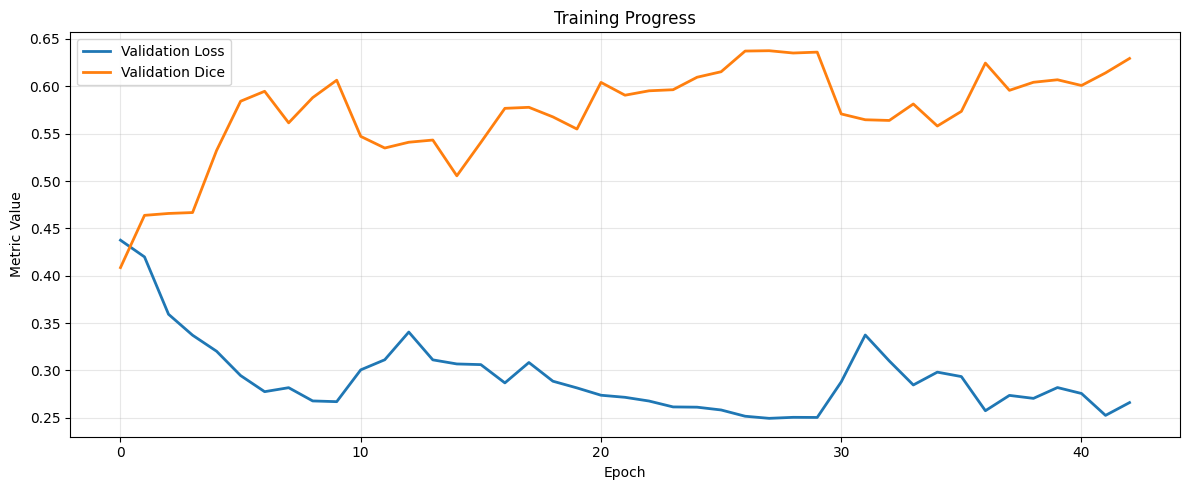

In [41]:
# %%
# =========================================================
# CELL 8 — TRAINING (FINAL STABLE VERSION)
# FIX FOR:
# AssertionError: No inf checks were recorded for this optimizer.
#
# Cause:
# PyTorch Lightning + Native AMP + manual teacher EMA updates can
# occasionally trigger this assertion.
#
# Solution:
# Use standard FP32 training (precision=32), which is extremely stable.
# You still retain:
# - EarlyStopping
# - ModelCheckpoint
# - SWA
# - Gradient clipping
# - Cosine Annealing LR
# =========================================================

from pytorch_lightning import Trainer
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    LearningRateMonitor,
    StochasticWeightAveraging,
)
import pandas as pd
import matplotlib.pyplot as plt
import os
import torch

# =========================================================
# LOGGER
# =========================================================

logger = CSVLogger(
    save_dir="logs",
    name="mlua_final"
)

# =========================================================
# MODEL
# =========================================================

model = MLUAModel()

# =========================================================
# CHECKPOINT CALLBACK
# =========================================================

checkpoint_callback = ModelCheckpoint(
    dirpath=None,                    # Lightning creates default checkpoint dir
    filename="best-model",
    monitor="val_dice",              # maximize Dice score
    mode="max",
    save_top_k=1,
    save_last=True,
    verbose=True,
)

# =========================================================
# EARLY STOPPING
# =========================================================

early_stopping = EarlyStopping(
    monitor="val_dice",
    mode="max",
    patience=15,
    min_delta=1e-4,
    verbose=True,
)

# =========================================================
# LEARNING RATE MONITOR
# =========================================================

lr_monitor = LearningRateMonitor(
    logging_interval="epoch"
)

# =========================================================
# STOCHASTIC WEIGHT AVERAGING (SWA)
# =========================================================

# Start averaging after 80% of training
swa_callback = StochasticWeightAveraging(
    swa_lrs=LR * 0.1,
    swa_epoch_start=0.8,
    annealing_epochs=5,
)

# =========================================================
# CALLBACK LIST
# =========================================================

callbacks = [
    checkpoint_callback,
    early_stopping,
    lr_monitor,
    swa_callback,
]

# =========================================================
# TRAINER
# =========================================================
# IMPORTANT:
# precision=32 avoids AMP assertion:
# "No inf checks were recorded for this optimizer."
# This is the most robust option for semi-supervised teacher-student training.

trainer = Trainer(
    # -----------------------------------------------------
    # TRAINING LENGTH
    # -----------------------------------------------------
    max_epochs=MAX_EPOCHS,

    # -----------------------------------------------------
    # DEVICE
    # -----------------------------------------------------
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,

    # -----------------------------------------------------
    # NUMERICAL STABILITY
    # -----------------------------------------------------
    precision=32,                    # <- critical fix

    # -----------------------------------------------------
    # GRADIENT CLIPPING
    # -----------------------------------------------------
    gradient_clip_val=1.0,
    gradient_clip_algorithm="norm",

    # -----------------------------------------------------
    # VALIDATION
    # -----------------------------------------------------
    check_val_every_n_epoch=1,

    # -----------------------------------------------------
    # LOGGING
    # -----------------------------------------------------
    logger=logger,
    log_every_n_steps=10,
    enable_progress_bar=True,
    enable_model_summary=True,

    # -----------------------------------------------------
    # CALLBACKS
    # -----------------------------------------------------
    callbacks=callbacks,

    # -----------------------------------------------------
    # PERFORMANCE
    # -----------------------------------------------------
    benchmark=True,

    # -----------------------------------------------------
    # DETERMINISM
    # -----------------------------------------------------
    deterministic=False,
)

# =========================================================
# START TRAINING
# =========================================================

print("=" * 80)
print("Starting Training...")
print("=" * 80)

trainer.fit(
    model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)

print("\nTraining Complete!")
print(f"Best Model Path : {checkpoint_callback.best_model_path}")
print(f"Best Val Dice   : {checkpoint_callback.best_model_score}")

# =========================================================
# LOAD BEST MODEL FOR EVALUATION
# =========================================================

best_model_path = checkpoint_callback.best_model_path

if best_model_path and os.path.exists(best_model_path):
    print("\nLoading best checkpoint...")
    model = MLUAModel.load_from_checkpoint(best_model_path)
    model = model.to(DEVICE)
    model.eval()

# =========================================================
# PLOT TRAINING CURVES
# =========================================================

metrics_path = os.path.join(logger.log_dir, "metrics.csv")

if os.path.exists(metrics_path):
    print("\nGenerating training plots...")

    df = pd.read_csv(metrics_path)

    plt.figure(figsize=(12, 5))

    # ---------------- TRAIN LOSS ----------------
    if "train_loss_epoch" in df.columns:
        train_df = df.dropna(subset=["train_loss_epoch"])
        plt.plot(
            train_df["epoch"],
            train_df["train_loss_epoch"],
            linewidth=2,
            label="Train Loss"
        )

    # ---------------- VALIDATION LOSS ----------------
    if "val_loss" in df.columns:
        val_df = df.dropna(subset=["val_loss"])
        plt.plot(
            val_df["epoch"],
            val_df["val_loss"],
            linewidth=2,
            label="Validation Loss"
        )

    # ---------------- VALIDATION DICE ----------------
    if "val_dice" in df.columns:
        dice_df = df.dropna(subset=["val_dice"])
        plt.plot(
            dice_df["epoch"],
            dice_df["val_dice"],
            linewidth=2,
            label="Validation Dice"
        )

    plt.xlabel("Epoch")
    plt.ylabel("Metric Value")
    plt.title("Training Progress")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("metrics.csv not found yet.")



Optimizing threshold on validation set...
Searching for optimal threshold...
Threshold = 0.10 | Mean Dice = 0.601300
Threshold = 0.12 | Mean Dice = 0.604755
Threshold = 0.14 | Mean Dice = 0.609708
Threshold = 0.16 | Mean Dice = 0.614125
Threshold = 0.18 | Mean Dice = 0.617481
Threshold = 0.20 | Mean Dice = 0.621272
Threshold = 0.22 | Mean Dice = 0.625702
Threshold = 0.24 | Mean Dice = 0.630065
Threshold = 0.26 | Mean Dice = 0.639964
Threshold = 0.28 | Mean Dice = 0.645076
Threshold = 0.30 | Mean Dice = 0.648510
Threshold = 0.32 | Mean Dice = 0.651222
Threshold = 0.34 | Mean Dice = 0.653642
Threshold = 0.36 | Mean Dice = 0.654974
Threshold = 0.38 | Mean Dice = 0.657578
Threshold = 0.40 | Mean Dice = 0.660054
Threshold = 0.42 | Mean Dice = 0.661997
Threshold = 0.44 | Mean Dice = 0.664517
Threshold = 0.46 | Mean Dice = 0.666739
Threshold = 0.48 | Mean Dice = 0.671124
Threshold = 0.50 | Mean Dice = 0.672134

Best Threshold : 0.50
Best Val Dice  : 0.672134

Evaluating on validation set wit

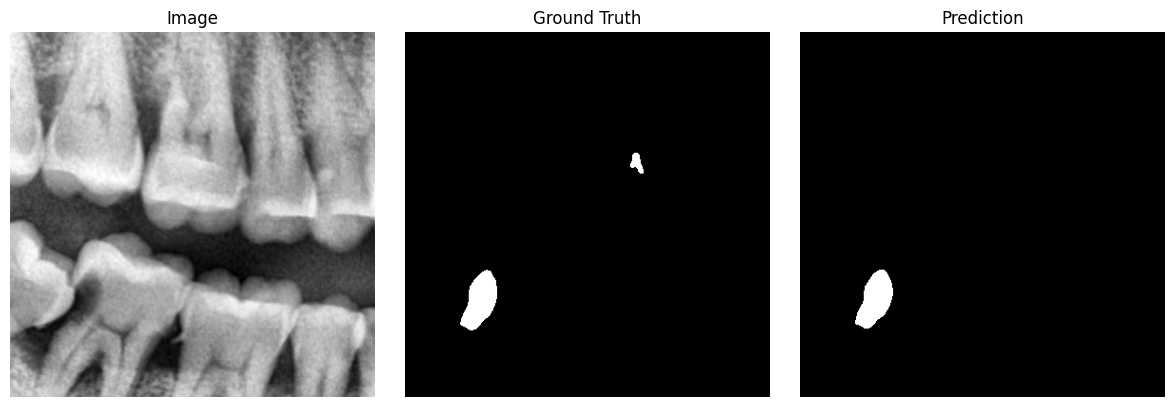

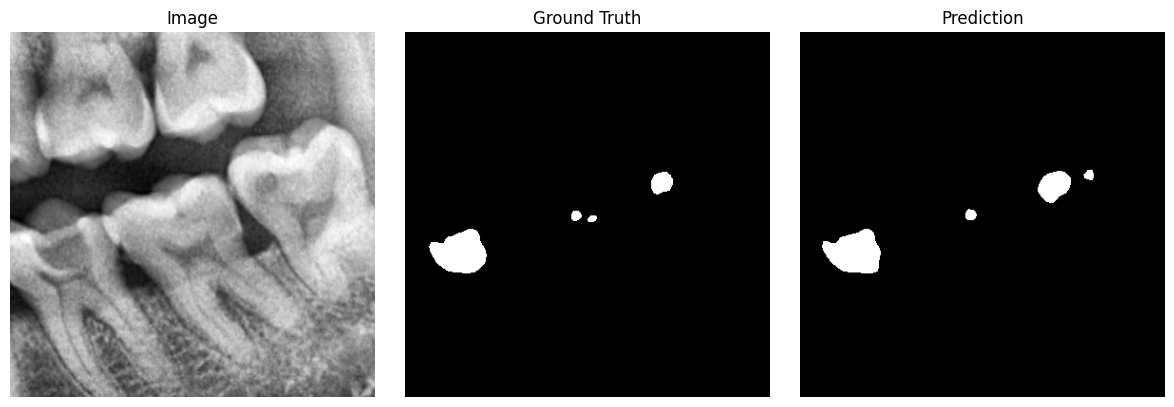

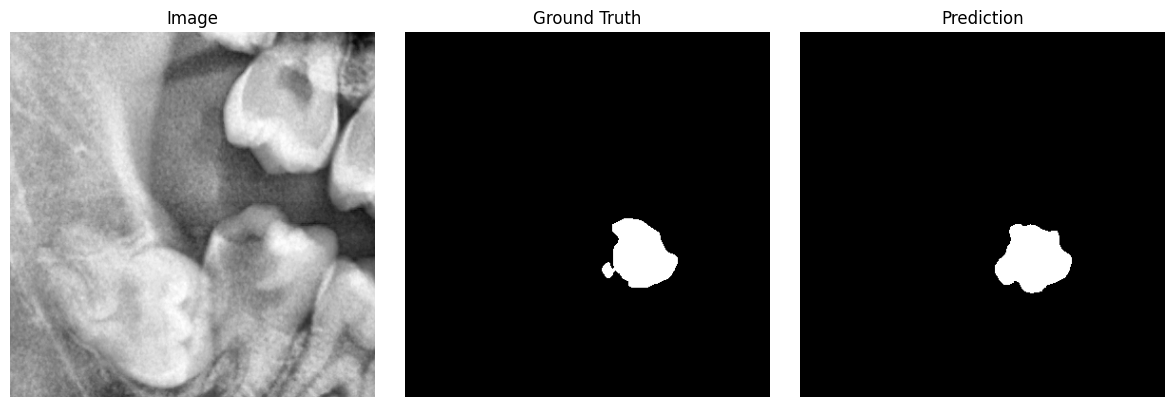

In [ ]:
# %%
# =========================================================
# CELL 9 — ADVANCED EVALUATION(Final Results)
# Test-Time Augmentation (TTA)
# Automatic Threshold Search
# Post-processing (Connected Component Filtering)
# =========================================================

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2


# =========================================================
# POST-PROCESSING
# =========================================================

def remove_small_components(mask, min_size=80):
    """
    Remove tiny isolated false-positive regions.

    Parameters
    ----------
    mask : np.ndarray
        Binary mask (0/1 or 0/255)
    min_size : int
        Minimum connected-component area to keep.

    Returns
    -------
    np.ndarray
        Cleaned binary mask (float32, values 0 or 1)
    """
    mask = (mask > 0).astype(np.uint8)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask,
        connectivity=8
    )

    cleaned = np.zeros_like(mask, dtype=np.uint8)

    for label_id in range(1, num_labels):  # skip background
        area = stats[label_id, cv2.CC_STAT_AREA]

        if area >= min_size:
            cleaned[labels == label_id] = 1

    return cleaned.astype(np.float32)


# =========================================================
# TEST-TIME AUGMENTATION
# =========================================================

def predict_with_tta(model, imgs):
    """
    Perform prediction using:
      1. Original
      2. Horizontal flip
      3. Vertical flip
      4. Horizontal + Vertical flip

    Returns averaged probability map.
    """
    device = next(model.parameters()).device
    imgs = imgs.to(device)

    predictions = []

    with torch.no_grad():
        # -------------------------------------------------
        # Original
        # -------------------------------------------------
        probs = torch.sigmoid(model(imgs))
        predictions.append(probs)

        # -------------------------------------------------
        # Horizontal Flip
        # -------------------------------------------------
        imgs_h = torch.flip(imgs, dims=[3])
        probs_h = torch.sigmoid(model(imgs_h))
        probs_h = torch.flip(probs_h, dims=[3])
        predictions.append(probs_h)

        # -------------------------------------------------
        # Vertical Flip
        # -------------------------------------------------
        imgs_v = torch.flip(imgs, dims=[2])
        probs_v = torch.sigmoid(model(imgs_v))
        probs_v = torch.flip(probs_v, dims=[2])
        predictions.append(probs_v)

        # -------------------------------------------------
        # Horizontal + Vertical Flip
        # -------------------------------------------------
        imgs_hv = torch.flip(imgs, dims=[2, 3])
        probs_hv = torch.sigmoid(model(imgs_hv))
        probs_hv = torch.flip(probs_hv, dims=[2, 3])
        predictions.append(probs_hv)

    # Average predictions
    mean_prediction = torch.stack(predictions, dim=0).mean(dim=0)

    return mean_prediction


# =========================================================
# AUTOMATIC THRESHOLD SEARCH
# =========================================================

def find_best_threshold(model, loader,
                        thresholds=np.arange(0.10, 0.51, 0.02),
                        min_component_size=80):
    """
    Search threshold maximizing mean validation Dice.
    """
    print("=" * 80)
    print("Searching for optimal threshold...")
    print("=" * 80)

    best_threshold = 0.25
    best_dice = -1.0

    for threshold in thresholds:
        dice_scores = []

        with torch.no_grad():
            for imgs, masks in loader:

                # TTA prediction
                probs = predict_with_tta(model, imgs)

                # Process each image in batch
                for b in range(probs.size(0)):
                    pred = probs[b, 0].cpu().numpy()
                    gt = masks[b, 0].numpy()

                    # Threshold
                    pred = (pred > threshold).astype(np.float32)

                    # Post-processing
                    pred = remove_small_components(
                        pred,
                        min_size=min_component_size
                    )

                    # Metrics
                    pred_t = torch.tensor(pred).unsqueeze(0).unsqueeze(0)
                    gt_t = torch.tensor(gt).unsqueeze(0).unsqueeze(0)

                    _, _, dice, _, _, _ = mean_metric(pred_t, gt_t)
                    dice_scores.append(dice.item())

        mean_dice = np.mean(dice_scores)

        print(
            f"Threshold = {threshold:.2f} | "
            f"Mean Dice = {mean_dice:.6f}"
        )

        if mean_dice > best_dice:
            best_dice = mean_dice
            best_threshold = threshold

    print("\n" + "=" * 80)
    print(f"Best Threshold : {best_threshold:.2f}")
    print(f"Best Val Dice  : {best_dice:.6f}")
    print("=" * 80)

    return float(best_threshold), float(best_dice)


# =========================================================
# MAIN EVALUATION FUNCTION
# =========================================================

def evaluate_model(model,
                   loader,
                   threshold=0.25,
                   use_tta=True,
                   min_component_size=80):
    """
    Full evaluation with:
      - Test-Time Augmentation
      - Thresholding
      - Connected-component filtering
    """
    model.eval()

    metrics = {
        "acc": [],
        "iou": [],
        "dice": [],
        "pre": [],
        "spe": [],
        "sen": []
    }

    with torch.no_grad():
        for imgs, masks in loader:

            # ---------------------------------------------
            # Prediction
            # ---------------------------------------------
            if use_tta:
                probs = predict_with_tta(model, imgs)
            else:
                imgs = imgs.to(next(model.parameters()).device)
                probs = torch.sigmoid(model(imgs))

            # ---------------------------------------------
            # Per-image evaluation
            # ---------------------------------------------
            for b in range(probs.size(0)):
                pred = probs[b, 0].cpu().numpy()
                gt = masks[b, 0].numpy()

                # Threshold
                pred = (pred > threshold).astype(np.float32)

                # Post-processing
                pred = remove_small_components(
                    pred,
                    min_size=min_component_size
                )

                # Convert to tensors
                pred_t = torch.tensor(pred).unsqueeze(0).unsqueeze(0)
                gt_t = torch.tensor(gt).unsqueeze(0).unsqueeze(0)

                # Compute metrics
                acc, iou, dice, pre, spe, sen = mean_metric(
                    pred_t,
                    gt_t
                )

                metrics["acc"].append(acc.item())
                metrics["iou"].append(iou.item())
                metrics["dice"].append(dice.item())
                metrics["pre"].append(pre.item())
                metrics["spe"].append(spe.item())
                metrics["sen"].append(sen.item())

    # Average all metrics
    final_metrics = {
        key: float(np.mean(values))
        for key, values in metrics.items()
    }

    return final_metrics


# =========================================================
# VISUALIZATION
# =========================================================

def visualize_predictions(model,
                          loader,
                          num_samples=3,
                          threshold=0.25,
                          use_tta=True,
                          min_component_size=80):
    """
    Visualize Image | Ground Truth | Prediction
    """
    model.eval()

    shown = 0

    with torch.no_grad():
        for imgs, masks in loader:

            # Prediction
            if use_tta:
                probs = predict_with_tta(model, imgs)
            else:
                probs = torch.sigmoid(
                    model(
                        imgs.to(next(model.parameters()).device)
                    )
                )

            for i in range(len(imgs)):
                # Input image (denormalized)
                img = imgs[i].cpu().squeeze().numpy()
                img = (img * 0.5) + 0.5
                img = np.clip(img, 0, 1)

                # Ground truth
                gt = masks[i].squeeze().numpy()

                # Prediction
                pred = probs[i, 0].cpu().numpy()
                pred = (pred > threshold).astype(np.float32)
                pred = remove_small_components(
                    pred,
                    min_size=min_component_size
                )

                # Plot
                plt.figure(figsize=(12, 4))

                plt.subplot(1, 3, 1)
                plt.imshow(img, cmap="gray")
                plt.title("Image")
                plt.axis("off")

                plt.subplot(1, 3, 2)
                plt.imshow(gt, cmap="gray")
                plt.title("Ground Truth")
                plt.axis("off")

                plt.subplot(1, 3, 3)
                plt.imshow(pred, cmap="gray")
                plt.title("Prediction")
                plt.axis("off")

                plt.tight_layout()
                plt.show()

                shown += 1
                if shown >= num_samples:
                    return


# =========================================================
# THRESHOLD OPTIMIZATION
# =========================================================

print("\nOptimizing threshold on final set...")
BEST_THRESHOLD, BEST_VAL_DICE = find_best_threshold(
    model,
    val_loader,
    thresholds=np.arange(0.10, 0.51, 0.02),
    min_component_size=80
)

# =========================================================
# FINAL EVALUATION
# =========================================================

print("\nEvaluating on final set with optimized threshold...")
val_metrics = evaluate_model(
    model,
    val_loader,
    threshold=BEST_THRESHOLD,
    use_tta=True,
    min_component_size=80
)

print("\n================ FINAL RESULTS ================")
for metric_name, metric_value in val_metrics.items():
    print(f"{metric_name.upper():4s}: {metric_value:.6f}")

# =========================================================
# VISUALIZATION
# =========================================================

print("\nSample Predictions:")
visualize_predictions(
    model,
    val_loader,
    num_samples=3,
    threshold=BEST_THRESHOLD,
    use_tta=True,
    min_component_size=80
)

